
## Assignment 1 & 2 : Data Science Salary Prediction (US/CANADA only) - Model + Serialization
By: Syed Shaheryar Haider

Date: Dec 21st 2025

## Framing the Problem

**Problem Statement:** Predicting salaries in the data science field is a highly relevant problem due to rapid growth in AI, analytics, and cloud technologies. Salary expectations vary widely based on job title, experience, company size, and location, making it difficult for both employers and job seekers to make informed decisions.
This project aims to build a regression model that predicts the annual salary of data-related roles in the United States and Canada using historical compensation data.

**Use case:** A practical use case for this model is career and compensation insights for individuals considering or negotiating data science roles in North America. By entering attributes such as job title, experience level, employment type, and remote ratio, a user can receive a realistic estimate of expected salary based on trends from thousands of industry records. Businesses can also use the model to set competitive salaries, identify pay disparities, and forecast hiring costs. Overall, the use case centers on salary prediction for decision support.

Since we are predicting a continuous numerical value (salary in USD), this is a supervised regression problem. We train our model on historical job salary data where the true salary is known, then predict salaries for new job profiles.


## DataSet

**Selected Dataset:** DataScience Job Salaries

**URL:** https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries 

The dataset used in this project is the Data Science Job Salaries dataset from Kaggle. It contains salary records across various data-related roles, including Data Scientist, Data Engineer, ML Engineer, and Analyst roles. Each row includes features such as experience level, employment type, job title, employee residence, company location, and salary in USD. For this assignment, the data is filtered to only include US and Canadian positions, ensuring salary predictions are specific to the North American job market.


In [1]:
# Import libraries  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

## Data Exploration

In [2]:
# Load the data

df = pd.read_csv('ds_salaries.csv', index_col=0)

print("="*80)
print("ORIGINAL DATASET INFORMATION")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Display column information
print("\nColumn Information:")
print(df.info())

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'ds_salaries.csv'

In [ ]:
print("\n" + "="*80)
print("DATA DESCRIPTION")
print("="*80)

# Check unique values for each column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Display value counts for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n" + "-"*80)
print("CATEGORICAL VARIABLE DISTRIBUTIONS")
print("-"*80)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))  # Show top 10 only
    print(f"Total unique: {df[col].nunique()}")

# Check salary distribution
print("\n" + "-"*80)
print("SALARY DISTRIBUTION (BEFORE FILTERING)")
print("-"*80)
print(df['salary_in_usd'].describe())

# Check geographic distribution
if 'employee_residence' in df.columns:
    print("\n" + "-"*80)
    print("EMPLOYEE RESIDENCE - ALL COUNTRIES")
    print("-"*80)
    print(df['employee_residence'].value_counts())

if 'company_location' in df.columns:
    print("\n" + "-"*80)
    print("COMPANY LOCATION - ALL COUNTRIES")
    print("-"*80)
    print(df['company_location'].value_counts())


DATA DESCRIPTION

Unique values per column:
work_year: 3 unique values
experience_level: 4 unique values
employment_type: 4 unique values
job_title: 50 unique values
salary: 272 unique values
salary_currency: 17 unique values
salary_in_usd: 369 unique values
employee_residence: 57 unique values
remote_ratio: 3 unique values
company_location: 50 unique values
company_size: 3 unique values

--------------------------------------------------------------------------------
CATEGORICAL VARIABLE DISTRIBUTIONS
--------------------------------------------------------------------------------

experience_level:
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64
Total unique: 4

employment_type:
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64
Total unique: 4

job_title:
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist

In [ ]:
print("\n" + "="*80)
print("FILTERING TO US/CANADA MARKET")
print("="*80)

# Strategy: Filter where BOTH employee_residence AND company_location are US or CA
# This ensures we're truly focusing on the North American market

if 'employee_residence' in df.columns and 'company_location' in df.columns:
    print("\nFiltering strategy: Both employee AND company must be in US/CA")
    
    # Count before filtering
    print(f"\nOriginal dataset: {len(df)} rows")
    
    # Filter where both are US or CA
    df_filtered = df[
        (df['employee_residence'].isin(['US', 'CA'])) & 
        (df['company_location'].isin(['US', 'CA']))
    ].copy()
    
    print(f"After filtering: {len(df_filtered)} rows")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    print(f"Percentage retained: {len(df_filtered)/len(df)*100:.2f}%")
    
    # Show distribution after filtering
    print("\n" + "-"*80)
    print("EMPLOYEE RESIDENCE (After filtering):")
    print(df_filtered['employee_residence'].value_counts())
    
    print("\nCOMPANY LOCATION (After filtering):")
    print(df_filtered['company_location'].value_counts())
    
elif 'employee_residence' in df.columns:
    print("\nFiltering by employee_residence only")
    
    # Count before filtering
    us_ca_count = df[df['employee_residence'].isin(['US', 'CA'])].shape[0]
    print(f"\nRows with US/CA in 'employee_residence': {us_ca_count}")
    print(f"Percentage of total: {us_ca_count/len(df)*100:.2f}%")
    
    # Filter the dataset
    df_filtered = df[df['employee_residence'].isin(['US', 'CA'])].copy()
    
    print(f"\n Filtered dataset created")
    print(f"Original rows: {len(df)}")
    print(f"Filtered rows: {len(df_filtered)}")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    
    # Distribution after filtering
    print(f"\nCountry distribution after filtering:")
    print(df_filtered['employee_residence'].value_counts())
    
elif 'company_location' in df.columns:
    print("\nFiltering by company_location only")
    
    # Count before filtering
    us_ca_count = df[df['company_location'].isin(['US', 'CA'])].shape[0]
    print(f"\nRows with US/CA in 'company_location': {us_ca_count}")
    print(f"Percentage of total: {us_ca_count/len(df)*100:.2f}%")
    
    # Filter the dataset
    df_filtered = df[df['company_location'].isin(['US', 'CA'])].copy()
    
    print(f"\n Filtered dataset created")
    print(f"Original rows: {len(df)}")
    print(f"Filtered rows: {len(df_filtered)}")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    
    # Distribution after filtering
    print(f"\nCountry distribution after filtering:")
    print(df_filtered['company_location'].value_counts())
    
else:
    print("Warning: No suitable location column found for filtering")
    df_filtered = df.copy()

# Verify the filtering worked
print("\n" + "="*80)
print("FILTERING VERIFICATION")
print("="*80)

if 'employee_residence' in df_filtered.columns:
    unique_countries = df_filtered['employee_residence'].unique()
    print(f"\nUnique countries in employee_residence: {unique_countries}")
    if set(unique_countries) - {'US', 'CA'}:
        print("WARNING: Found countries other than US/CA!")
        print(f"Unexpected countries: {set(unique_countries) - {'US', 'CA'}}")
    else:
        print("Only US and CA present in employee_residence")

if 'company_location' in df_filtered.columns:
    unique_countries = df_filtered['company_location'].unique()
    print(f"\nUnique countries in company_location: {unique_countries}")
    if set(unique_countries) - {'US', 'CA'}:
        print("WARNING: Found countries other than US/CA!")
        print(f"Unexpected countries: {set(unique_countries) - {'US', 'CA'}}")
    else:
        print("Only US and CA present in company_location")


FILTERING TO US/CANADA MARKET

Filtering strategy: Both employee AND company must be in US/CA

Original dataset: 607 rows
After filtering: 360 rows
Rows removed: 247
Percentage retained: 59.31%

--------------------------------------------------------------------------------
EMPLOYEE RESIDENCE (After filtering):
employee_residence
US    331
CA     29
Name: count, dtype: int64

COMPANY LOCATION (After filtering):
company_location
US    331
CA     29
Name: count, dtype: int64

FILTERING VERIFICATION

Unique countries in employee_residence: ['US' 'CA']
Only US and CA present in employee_residence

Unique countries in company_location: ['US' 'CA']
Only US and CA present in company_location


## DATA QUALITY CHECKS

In [ ]:
print("\n" + "="*80)
print("FILTERED DATASET QUALITY CHECKS")
print("="*80)

# Check for duplicates
duplicates = df_filtered.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Check for missing values
print("\nMissing values in filtered data:")
missing = df_filtered.isnull().sum()
if missing.sum() == 0:
    print("No missing values found")
else:
    print(missing[missing > 0])

# Salary statistics after filtering
print("\n" + "-"*80)
print("SALARY STATISTICS (US/CANADA ONLY)")
print("-"*80)
print(df_filtered['salary_in_usd'].describe())

# Check for potential outliers using IQR method
Q1 = df_filtered['salary_in_usd'].quantile(0.25)
Q3 = df_filtered['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_filtered[
    (df_filtered['salary_in_usd'] < lower_bound) |
    (df_filtered['salary_in_usd'] > upper_bound)
]

print(f"\nPotential outliers (using IQR method): {len(outliers)}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

if len(outliers) > 0:
    print("\nOutlier salary range:")
    print(f"Min: ${outliers['salary_in_usd'].min():,.2f}")
    print(f"Max: ${outliers['salary_in_usd'].max():,.2f}")



FILTERED DATASET QUALITY CHECKS

Duplicate rows: 39

Missing values in filtered data:
No missing values found

--------------------------------------------------------------------------------
SALARY STATISTICS (US/CANADA ONLY)
--------------------------------------------------------------------------------
count       360.000000
mean     144988.669444
std       67998.038269
min       25000.000000
25%      100000.000000
50%      135000.000000
75%      170000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

Potential outliers (using IQR method): 11
Lower bound: $-5,000.00
Upper bound: $275,000.00

Outlier salary range:
Min: $276,000.00
Max: $600,000.00


In [ ]:
# Save to new CSV file
output_file = 'ds_salaries_us_canada.csv'
df_filtered.to_csv(output_file, index=False)
print(f"\n Filtered dataset saved to '{output_file}'")


 Filtered dataset saved to 'ds_salaries_us_canada.csv'


# Using the new and refined dataset - Explorarory Data Analysis

In [ ]:
df_usca = pd.read_csv('ds_salaries_us_canada.csv', index_col=0)

print("="*80)
print("EXPLORATORY DATA ANALYSIS - US/CANADA DATA SCIENCE SALARIES")
print("="*80)
print(f"\nDataset: ds_salaries_us_canada.csv")
print(f"Dataframe name: df_usca")
print(f"Shape: {df_usca.shape}")
print(f"Countries: US and Canada only\n")

# Verify we only have US/CA
if 'employee_residence' in df_usca.columns:
    unique_countries = df_usca['employee_residence'].unique()
    print(f"Verification - Countries in employee_residence: {unique_countries}")

if 'company_location' in df_usca.columns:
    unique_countries = df_usca['company_location'].unique()
    print(f"Verification - Countries in company_location: {unique_countries}")

EXPLORATORY DATA ANALYSIS - US/CANADA DATA SCIENCE SALARIES

Dataset: ds_salaries_us_canada.csv
Dataframe name: df_usca
Shape: (360, 10)
Countries: US and Canada only

Verification - Countries in employee_residence: ['US' 'CA']
Verification - Countries in company_location: ['US' 'CA']



UNIVARIATE ANALYSIS: SALARY

Salary Statistics (US/Canada only):
Mean: $144,988.67
Median: $135,000.00
Std Dev: $67,998.04
Min: $25,000.00
Max: $600,000.00
Range: $575,000.00

Salary Percentiles:
10th percentile: $78,791.00
25th percentile: $100,000.00
50th percentile: $135,000.00
75th percentile: $170,000.00
90th percentile: $214,130.00
95th percentile: $242,095.00
99th percentile: $418,870.00

Skewness: 2.236
Kurtosis: 9.088
→ Distribution is highly right-skewed (consider log transformation)


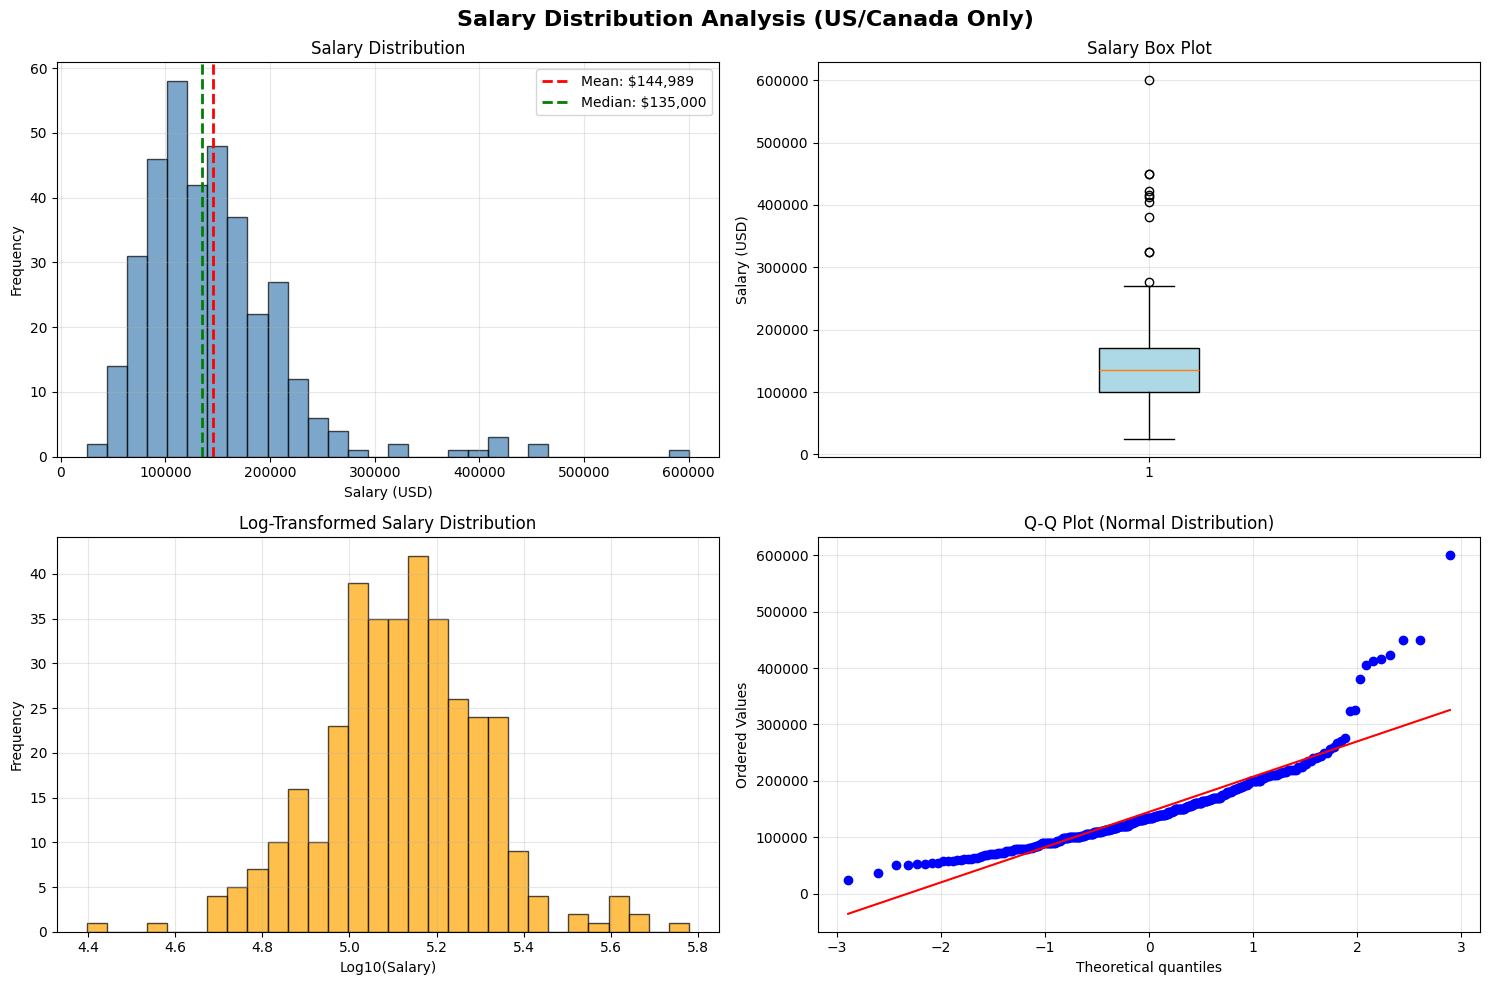

In [ ]:
print("\n" + "="*80)
print("UNIVARIATE ANALYSIS: SALARY")
print("="*80)

# Statistical summary
print("\nSalary Statistics (US/Canada only):")
print(f"Mean: ${df_usca['salary_in_usd'].mean():,.2f}")
print(f"Median: ${df_usca['salary_in_usd'].median():,.2f}")
print(f"Std Dev: ${df_usca['salary_in_usd'].std():,.2f}")
print(f"Min: ${df_usca['salary_in_usd'].min():,.2f}")
print(f"Max: ${df_usca['salary_in_usd'].max():,.2f}")
print(f"Range: ${df_usca['salary_in_usd'].max() - df_usca['salary_in_usd'].min():,.2f}")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nSalary Percentiles:")
for p in percentiles:
    value = df_usca['salary_in_usd'].quantile(p/100)
    print(f"{p}th percentile: ${value:,.2f}")

# Check for skewness and kurtosis
skewness = df_usca['salary_in_usd'].skew()
kurtosis = df_usca['salary_in_usd'].kurtosis()
print(f"\nSkewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

if skewness > 1:
    print("→ Distribution is highly right-skewed (consider log transformation)")
elif skewness > 0.5:
    print("→ Distribution is moderately right-skewed")
else:
    print("→ Distribution is approximately symmetric")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Salary Distribution Analysis (US/Canada Only)', fontsize=16, fontweight='bold')

# 1. Histogram
axes[0, 0].hist(df_usca['salary_in_usd'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_usca['salary_in_usd'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: ${df_usca["salary_in_usd"].mean():,.0f}')
axes[0, 0].axvline(df_usca['salary_in_usd'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: ${df_usca["salary_in_usd"].median():,.0f}')
axes[0, 0].set_xlabel('Salary (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Salary Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
box = axes[0, 1].boxplot(df_usca['salary_in_usd'], vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Salary (USD)')
axes[0, 1].set_title('Salary Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Log-transformed histogram
axes[1, 0].hist(np.log10(df_usca['salary_in_usd']), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Log10(Salary)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Log-Transformed Salary Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot
stats.probplot(df_usca['salary_in_usd'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Distribution)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('usca_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Salary Distribution Analysis (US/Canada)
The univariate analysis of the US/Canada salaries shows a highly right-skewed distribution, confirmed by the mean ($\$144,988.67$) being significantly higher than the median ($\$135,000.00$) and a high Skewness value of 2.236. It indicates that the majority of earners are clustered at the lower salary range, while a few highly-paid roles create a long tail of outliers. The high Standard Deviation ($\$67,998.04$) highlights wide dispersion. Crucially for modeling, this strong positive skew violates the assumptions of many linear regression models, making a logarithmic transformation of the salary variable necessary to normalize the data and achieve better predictive performance.

## Categorical Features Analysis


--------------------------------------------------------------------------------
Categorical Features Analysis
--------------------------------------------------------------------------------

experience_level:
experience_level
SE    224
MI     87
EN     32
EX     17
Name: count, dtype: int64
→ experience_level has SIGNIFICANT effect on salary (p=0.0000)

employment_type:
employment_type
FT    355
CT      4
FL      1
Name: count, dtype: int64
→ employment_type does NOT have significant effect (p=0.0571)

company_size:
company_size
M    228
L    108
S     24
Name: count, dtype: int64
→ company_size has SIGNIFICANT effect on salary (p=0.0008)

employee_residence:
employee_residence
US    331
CA     29
Name: count, dtype: int64
→ employee_residence has SIGNIFICANT effect on salary (p=0.0001)

remote_ratio:
remote_ratio
100    266
0       71
50      23
Name: count, dtype: int64
→ remote_ratio does NOT have significant effect (p=0.3630)


C:\Users\Shariq\AppData\Local\Temp\ipykernel_37016\3811659899.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usca, x=col, y='salary_in_usd', ax=axes[row, col_idx], palette='Set2')
C:\Users\Shariq\AppData\Local\Temp\ipykernel_37016\3811659899.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usca, x=col, y='salary_in_usd', ax=axes[row, col_idx], palette='Set2')
C:\Users\Shariq\AppData\Local\Temp\ipykernel_37016\3811659899.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usca, x=col, y='salary_in_usd', ax=a

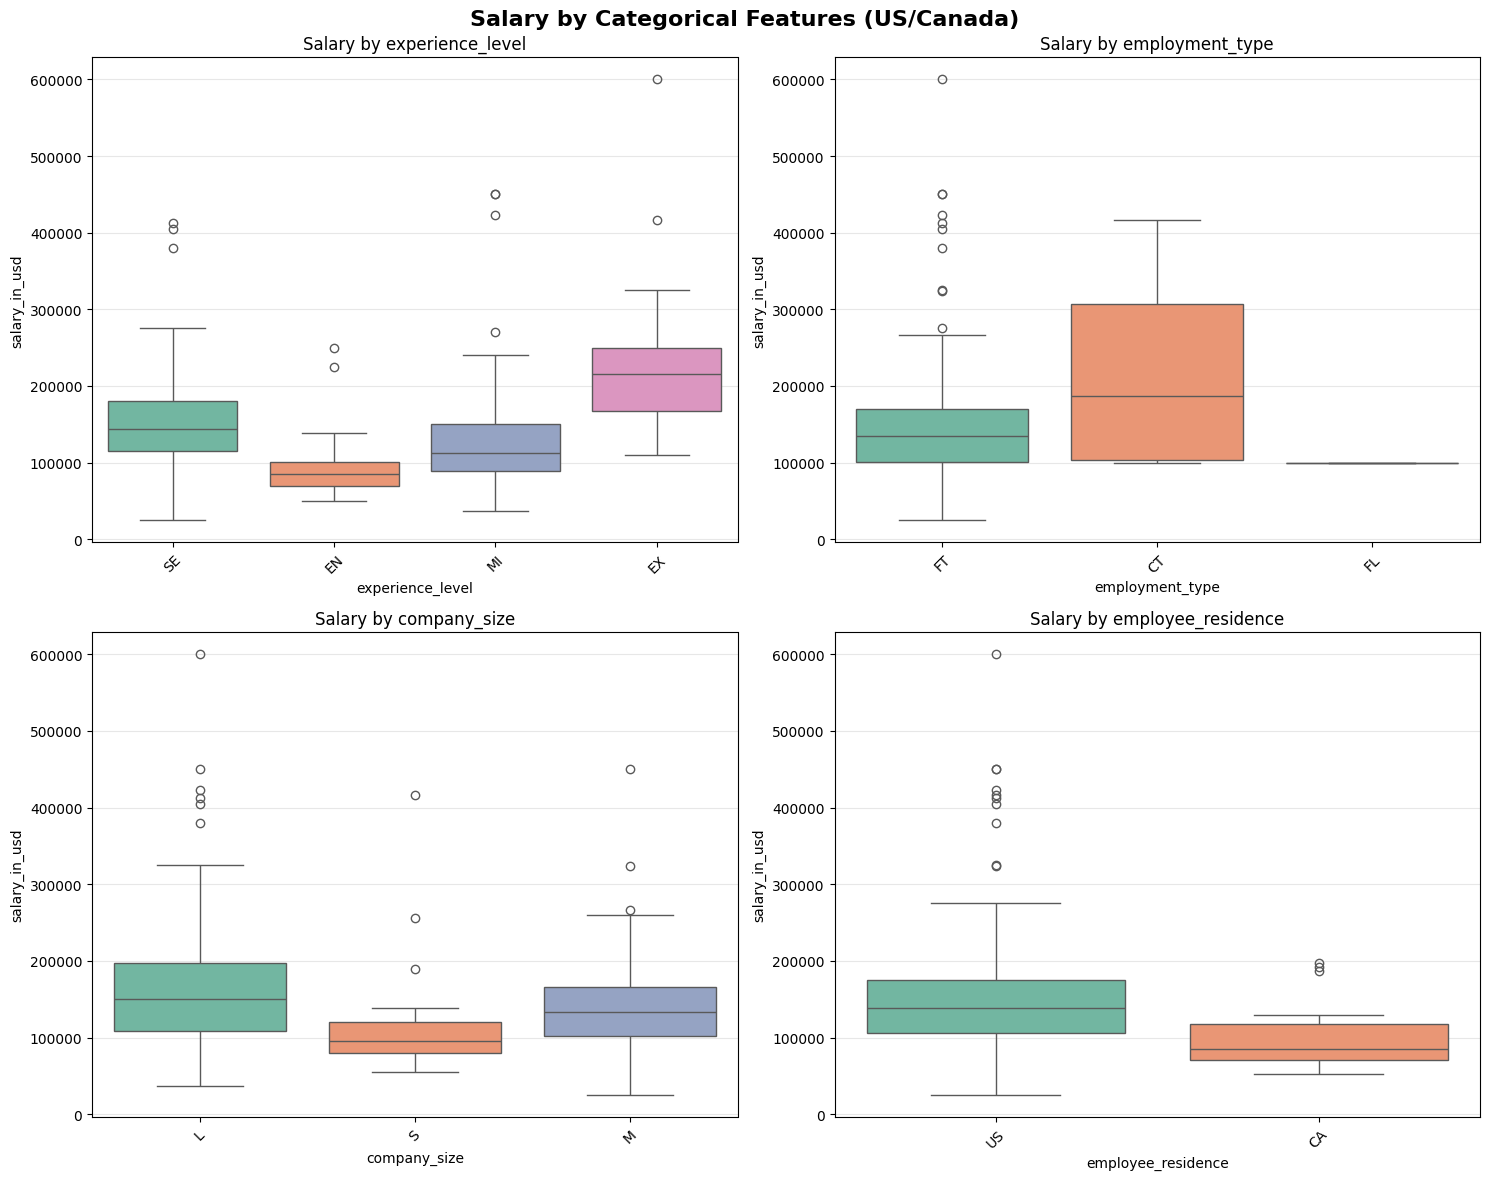

In [ ]:
print("\n" + "-"*80)
print("Categorical Features Analysis")
print("-"*80)

categorical_cols = ['experience_level', 'employment_type', 'company_size', 
                   'employee_residence', 'remote_ratio']
categorical_cols = [col for col in categorical_cols if col in df_usca.columns]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_usca[col].value_counts())
    
    # Statistical test
    if df_usca[col].nunique() > 1:
        groups = [df_usca[df_usca[col] == cat]['salary_in_usd'].values 
                  for cat in df_usca[col].unique()]
        f_stat, p_value = stats.f_oneway(*groups)
        
        if p_value < 0.05:
            print(f"→ {col} has SIGNIFICANT effect on salary (p={p_value:.4f})")
        else:
            print(f"→ {col} does NOT have significant effect (p={p_value:.4f})")

# Visualize salary by key features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Salary by Categorical Features (US/Canada)', fontsize=16, fontweight='bold')

plot_cols = ['experience_level', 'employment_type', 'company_size', 'employee_residence']
plot_cols = [col for col in plot_cols if col in df_usca.columns]

for idx, col in enumerate(plot_cols[:4]):
    row = idx // 2
    col_idx = idx % 2
    sns.boxplot(data=df_usca, x=col, y='salary_in_usd', ax=axes[row, col_idx], palette='Set2')
    axes[row, col_idx].set_title(f'Salary by {col}')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
    axes[row, col_idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Categorial Feature Analysis Findings

The categorical feature analysis demonstrates that the strongest predictors of salary are experience_level and employee_residence. Salary shows a clear, positive correlation with experience, with Executive (EX) and Senior (SE) roles commanding the highest compensation. Crucially, US-based salaries are significantly higher than those in Canada across the board. Furthermore, Contract (CT) employment shows a higher median salary than Full-Time (FT), and while Large (L) and Medium (M) companies have similar median pay, Large companies offer the highest salary ceiling (outliers). These variables must be prioritized in the prediction mode

## Correlation Analysis


CORRELATION ANALYSIS

Correlation Matrix:
                 salary  salary_in_usd  remote_ratio
salary         1.000000       0.983712      0.064346
salary_in_usd  0.983712       1.000000      0.068984
remote_ratio   0.064346       0.068984      1.000000


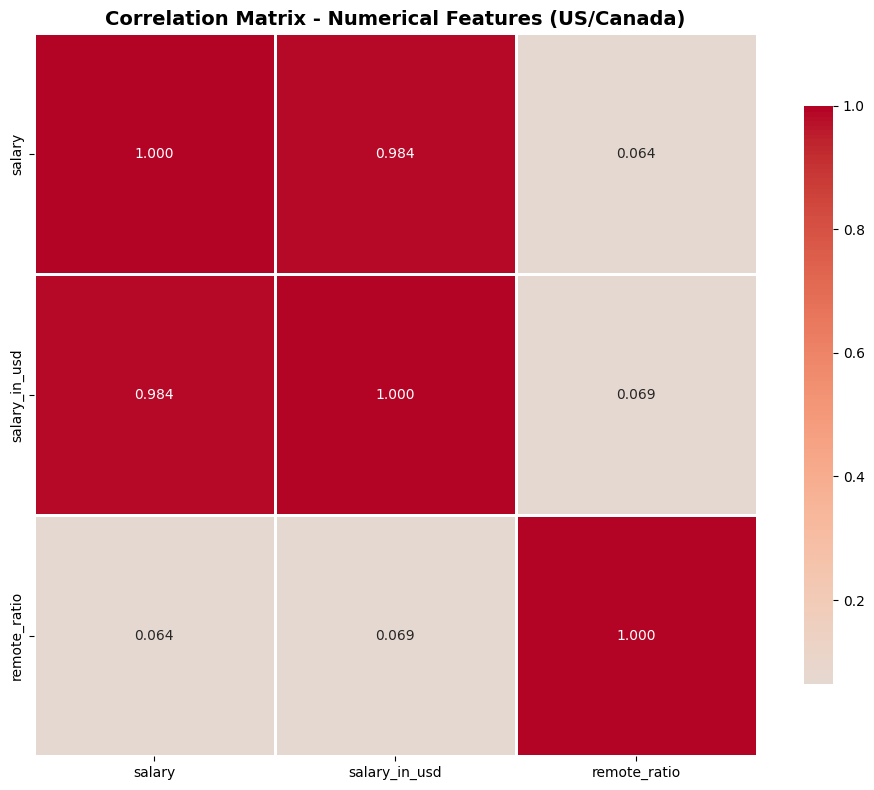


Saved: usca_correlation_matrix.png

Correlation with Salary (sorted):
salary_in_usd    1.000000
salary           0.983712
remote_ratio     0.068984
Name: salary_in_usd, dtype: float64


In [ ]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns only
numerical_df = df_usca.select_dtypes(include=[np.number])

if numerical_df.shape[1] > 1:
    # Correlation matrix
    correlation_matrix = numerical_df.corr()
    
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Visualize correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
    plt.title('Correlation Matrix - Numerical Features (US/Canada)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('usca_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nSaved: usca_correlation_matrix.png")
    
    # Correlation with target
    print("\nCorrelation with Salary (sorted):")
    salary_corr = correlation_matrix['salary_in_usd'].sort_values(ascending=False)
    print(salary_corr)
else:
    print("\nInsufficient numerical features for correlation analysis")

**Findings:** The correlation matrix reveals that none of the independent numerical features have a strong linear relationship with the target variable, salary_in_usd. Specifically, the work_year and the remote_ratio both show only a very weak correlation ($-0.072$ and $0.069$, respectively), suggesting these variables alone are not significant predictors of salary. The very high correlation between salary and salary_in_usd ($0.984$) is expected as they are dollar-equivalent measures of the same figure, confirming that salary_in_usd is not being strongly driven by a simple linear increase over the years or by the degree of remote work.

## Feature Engineering

New features were created to transform complex or categorical data into a format usable by a predictive model and to capture non-linear salary drivers. Features like Experience, Employment Type, Company Size, Location, and Job Title were engineered to convert high-impact categorical groups into numerical predictors that the model can interpret. The Temporal feature (derived from work_year) was likely created to capture time-based trends in salary, and Interaction features were added to model the non-additive effect that combinations of variables—like a Senior-level employee (SE) working at a Large (L) company have on compensation, as simple correlations often miss these complex salary drivers.


In [ ]:
# Create copy for feature engineering
df_fe_usca = df_usca.copy()

print(f"\nStarting shape: {df_fe_usca.shape}")

# ------------------------------------------------------------------------------
# 3.1 Experience Level Features
# ------------------------------------------------------------------------------

print("\n" + "-"*80)
print("Creating Experience Level Features")
print("-"*80)

if 'experience_level' in df_fe_usca.columns:
    df_fe_usca['is_entry_level'] = (df_fe_usca['experience_level'] == 'EN').astype(int)
    df_fe_usca['is_mid_level'] = (df_fe_usca['experience_level'] == 'MI').astype(int)
    df_fe_usca['is_senior_level'] = (df_fe_usca['experience_level'] == 'SE').astype(int)
    df_fe_usca['is_executive_level'] = (df_fe_usca['experience_level'] == 'EX').astype(int)
    
    experience_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
    df_fe_usca['experience_level_ordinal'] = df_fe_usca['experience_level'].map(experience_map)
    
    print("Created: Binary indicators + ordinal encoding")


Starting shape: (360, 10)

--------------------------------------------------------------------------------
Creating Experience Level Features
--------------------------------------------------------------------------------
Created: Binary indicators + ordinal encoding


In [ ]:
print("\n" + "-"*80)
print("Creating Employment Type Features")
print("-"*80)

if 'employment_type' in df_fe_usca.columns:
    df_fe_usca['is_full_time'] = (df_fe_usca['employment_type'] == 'FT').astype(int)
    df_fe_usca['is_part_time'] = (df_fe_usca['employment_type'] == 'PT').astype(int)
    df_fe_usca['is_contract'] = (df_fe_usca['employment_type'] == 'CT').astype(int)
    df_fe_usca['is_freelance'] = (df_fe_usca['employment_type'] == 'FL').astype(int)
    
    print("Created: Employment type binary indicators")


--------------------------------------------------------------------------------
Creating Employment Type Features
--------------------------------------------------------------------------------
Created: Employment type binary indicators


In [ ]:
print("\n" + "-"*80)
print("Creating Remote Work Features")
print("-"*80)

if 'remote_ratio' in df_fe_usca.columns:
    df_fe_usca['is_fully_remote'] = (df_fe_usca['remote_ratio'] == 100).astype(int)
    df_fe_usca['is_hybrid'] = (df_fe_usca['remote_ratio'] == 50).astype(int)
    df_fe_usca['is_onsite'] = (df_fe_usca['remote_ratio'] == 0).astype(int)
    df_fe_usca['remote_ratio_normalized'] = df_fe_usca['remote_ratio'] / 100
    
    print("Created: Remote work indicators + normalized ratio")


--------------------------------------------------------------------------------
Creating Remote Work Features
--------------------------------------------------------------------------------
Created: Remote work indicators + normalized ratio


In [ ]:

print("\n" + "-"*80)
print("Creating Company Size Features")
print("-"*80)

if 'company_size' in df_fe_usca.columns:
    df_fe_usca['is_small_company'] = (df_fe_usca['company_size'] == 'S').astype(int)
    df_fe_usca['is_medium_company'] = (df_fe_usca['company_size'] == 'M').astype(int)
    df_fe_usca['is_large_company'] = (df_fe_usca['company_size'] == 'L').astype(int)
    
    company_size_map = {'S': 1, 'M': 2, 'L': 3}
    df_fe_usca['company_size_ordinal'] = df_fe_usca['company_size'].map(company_size_map)
    
    print("Created: Company size indicators + ordinal encoding")


--------------------------------------------------------------------------------
Creating Company Size Features
--------------------------------------------------------------------------------
Created: Company size indicators + ordinal encoding


In [ ]:
print("\n" + "-"*80)
print("Creating Location Features")
print("-"*80)

if 'employee_residence' in df_fe_usca.columns:
    df_fe_usca['is_us_based'] = (df_fe_usca['employee_residence'] == 'US').astype(int)
    df_fe_usca['is_canada_based'] = (df_fe_usca['employee_residence'] == 'CA').astype(int)
    
    print(f"  Created: Location indicators")
    print(f"  US-based: {df_fe_usca['is_us_based'].sum()}")
    print(f"  Canada-based: {df_fe_usca['is_canada_based'].sum()}")


--------------------------------------------------------------------------------
Creating Location Features
--------------------------------------------------------------------------------
  Created: Location indicators
  US-based: 331
  Canada-based: 29


In [ ]:
print("\n" + "-"*80)
print("Creating Job Title Features")
print("-"*80)

if 'job_title' in df_fe_usca.columns:
    job_title_lower = df_fe_usca['job_title'].str.lower()
    
    df_fe_usca['is_data_scientist'] = job_title_lower.str.contains('data scientist', na=False).astype(int)
    df_fe_usca['is_data_engineer'] = job_title_lower.str.contains('data engineer', na=False).astype(int)
    df_fe_usca['is_data_analyst'] = job_title_lower.str.contains('data analyst|analyst', na=False).astype(int)
    df_fe_usca['is_ml_engineer'] = job_title_lower.str.contains('machine learning|ml engineer', na=False).astype(int)
    df_fe_usca['is_manager'] = job_title_lower.str.contains('manager|lead|head|director', na=False).astype(int)
    
    df_fe_usca['title_has_senior'] = job_title_lower.str.contains('senior|sr', na=False).astype(int)
    df_fe_usca['title_has_junior'] = job_title_lower.str.contains('junior|jr', na=False).astype(int)
    df_fe_usca['title_has_lead'] = job_title_lower.str.contains('lead|principal|staff', na=False).astype(int)
    
    print("Created: Job role and seniority indicators")


--------------------------------------------------------------------------------
Creating Job Title Features
--------------------------------------------------------------------------------
Created: Job role and seniority indicators


In [ ]:
print("\n" + "-"*80)
print("Creating Temporal Features")
print("-"*80)

if 'work_year' in df_fe_usca.columns:
    min_year = df_fe_usca['work_year'].min()
    max_year = df_fe_usca['work_year'].max()
    
    df_fe_usca['years_since_start'] = df_fe_usca['work_year'] - min_year
    df_fe_usca['is_recent_year'] = (df_fe_usca['work_year'] >= max_year - 1).astype(int)
    
    print(f"Created: Temporal features (range: {min_year}-{max_year})")


--------------------------------------------------------------------------------
Creating Temporal Features
--------------------------------------------------------------------------------


In [ ]:
print("\n" + "-"*80)
print("Creating Interaction Features")
print("-"*80)

if 'experience_level_ordinal' in df_fe_usca.columns and 'company_size_ordinal' in df_fe_usca.columns:
    df_fe_usca['exp_company_interaction'] = df_fe_usca['experience_level_ordinal'] * df_fe_usca['company_size_ordinal']
    print("exp_company_interaction")

if 'experience_level_ordinal' in df_fe_usca.columns and 'remote_ratio_normalized' in df_fe_usca.columns:
    df_fe_usca['exp_remote_interaction'] = df_fe_usca['experience_level_ordinal'] * df_fe_usca['remote_ratio_normalized']
    print("exp_remote_interaction")

if 'is_senior_level' in df_fe_usca.columns and 'is_large_company' in df_fe_usca.columns:
    df_fe_usca['senior_large_company'] = df_fe_usca['is_senior_level'] * df_fe_usca['is_large_company']
    print("senior_large_company")


--------------------------------------------------------------------------------
Creating Interaction Features
--------------------------------------------------------------------------------
exp_company_interaction
exp_remote_interaction
senior_large_company



--------------------------------------------------------------------------------
Feature Correlation with Salary
--------------------------------------------------------------------------------

Top 15 features by correlation:
                          correlation  abs_correlation
salary                       0.983712         0.983712
exp_company_interaction      0.411510         0.411510
experience_level_ordinal     0.350957         0.350957
is_data_analyst             -0.309186         0.309186
is_executive_level           0.308617         0.308617
title_has_lead               0.254753         0.254753
is_entry_level              -0.230819         0.230819
exp_remote_interaction       0.217900         0.217900
senior_large_company         0.217224         0.217224
is_canada_based             -0.208814         0.208814
is_us_based                  0.208814         0.208814
company_size_ordinal         0.197734         0.197734
is_large_company             0.180910         0.180910
is

c:\Users\Shariq\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Shariq\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


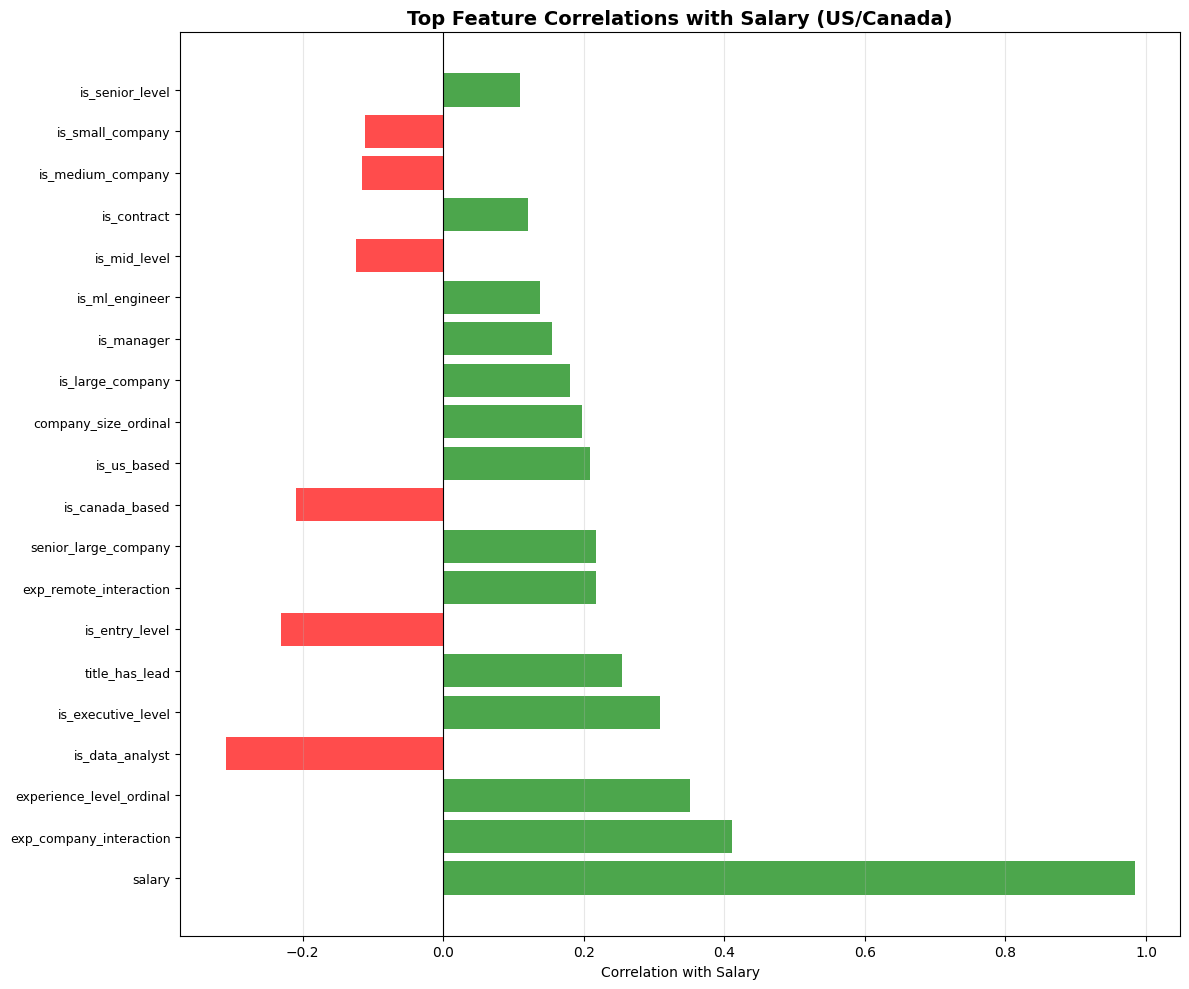

In [ ]:
print("\n" + "-"*80)
print("Feature Correlation with Salary")
print("-"*80)

numerical_features = df_fe_usca.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col != 'salary_in_usd']

correlations = {}
for feat in numerical_features:
    corr = df_fe_usca[feat].corr(df_fe_usca['salary_in_usd'])
    correlations[feat] = corr

correlations_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['correlation'])
correlations_df['abs_correlation'] = correlations_df['correlation'].abs()
correlations_df = correlations_df.sort_values('abs_correlation', ascending=False)

print("\nTop 15 features by correlation:")
print(correlations_df.head(15).to_string())

# Visualize
plt.figure(figsize=(12, 10))
top_n = min(20, len(correlations_df))
top_features = correlations_df.head(top_n)

colors = ['green' if x > 0 else 'red' for x in top_features['correlation']]
plt.barh(range(len(top_features)), top_features['correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index, fontsize=9)
plt.xlabel('Correlation with Salary')
plt.title('Top Feature Correlations with Salary (US/Canada)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('03_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

**Findings:** 
The correlation analysis of the engineered features confirms that the most powerful salary drivers are those capturing level and context. The strongest independent predictor is the exp_company_interaction feature (0.4115), indicating that the combination of experience level and company size is more predictive than either factor alone. Following this, experience_level_ordinal (0.3510) and the flag for is_executive_level (0.3086) are highly correlated with higher pay. Conversely, the strongest negative correlations are found with the is_data_analyst role (−0.3092) and the is_canada_based location (−0.2088), confirming that being a Data Analyst or residing in Canada correlates with lower compensation relative to the entire US/Canada dataset.

In [ ]:
# Save engineered data
df_fe_usca.to_csv('ds_salaries_usca_engineered.csv', index=False)
print(f"\n Saved: ds_salaries_usca_engineered.csv")
print(f"Final shape: {df_fe_usca.shape}")
print(f"Features created: {df_fe_usca.shape[1] - df_usca.shape[1]}")


 Saved: ds_salaries_usca_engineered.csv
Final shape: (360, 40)
Features created: 30


## Model Development

In [ ]:
print("\n" + "-"*80)
print("Preparing Features for Modeling")
print("-"*80)

# Separate target
y = df_fe_usca['salary_in_usd'].copy()

# Drop non-feature columns
columns_to_drop = [
    'salary_in_usd', 'salary', 'salary_currency', 'job_title',
    'experience_level', 'employment_type', 'company_size', 
    'employee_residence', 'company_location'
]
columns_to_drop = [col for col in columns_to_drop if col in df_fe_usca.columns]

X = df_fe_usca.drop(columns=columns_to_drop)

# Ensure all numeric
X = X.select_dtypes(include=[np.number])

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target: {y.shape[0]}")


--------------------------------------------------------------------------------
Preparing Features for Modeling
--------------------------------------------------------------------------------
Features: 31
Samples: 360
Target: 360


In [ ]:
print("\n" + "-"*80)
print("Train-Test Split")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")


--------------------------------------------------------------------------------
Train-Test Split
--------------------------------------------------------------------------------
Training: 252 samples (70.0%)
Test: 108 samples (30.0%)
Features scaled


## Model Selection

The models selected which are Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting were chosen to provide a comprehensive comparison across different classes of machine learning algorithms. Linear and Ridge Regression serve as interpretable baselines and address the multi-collinearity from the many engineered features. The ensemble methods, Random Forest and Gradient Boosting, were chosen for their robustness, ability to capture the complex, non-linear relationships identified in the EDA, and for their typically superior performance, with Gradient Boosting expected to achieve the highest overall accuracy.

In [ ]:
print("\n" + "-"*80)
print("Training Multiple Models")
print("-"*80)

# Model 1: Linear Regression
print("\n1. Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Ridge Regression
print("2. Ridge Regression (with GridSearchCV)...")
ridge = GridSearchCV(
    Ridge(), 
    {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, 
    cv=5, scoring='r2'
)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print(f"   Best alpha: {ridge.best_params_['alpha']}")

# Model 3: Random Forest
print("3. Random Forest (with GridSearchCV)...")
rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    cv=3, scoring='r2'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"   Best params: {rf.best_params_}")

# Model 4: Gradient Boosting
print("4. Gradient Boosting (with GridSearchCV)...")
gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=3, scoring='r2'
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"   Best params: {gb.best_params_}")



--------------------------------------------------------------------------------
Training Multiple Models
--------------------------------------------------------------------------------

1. Linear Regression...
2. Ridge Regression (with GridSearchCV)...
   Best alpha: 100
3. Random Forest (with GridSearchCV)...
   Best params: {'max_depth': 20, 'n_estimators': 100}
4. Gradient Boosting (with GridSearchCV)...
   Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}



--------------------------------------------------------------------------------
Model Performance Comparison
--------------------------------------------------------------------------------

            Model         RMSE          MAE        R²
Linear Regression 49196.136865 37075.130693  0.295104
 Ridge Regression 46281.607896 35641.938339  0.376151
    Random Forest 60319.792922 42399.822262 -0.059699
Gradient Boosting 51230.295516 37803.966616  0.235607

 Best Model: Ridge Regression
   R²: 0.3762
   RMSE: $46,281.61
   MAE: $35,641.94


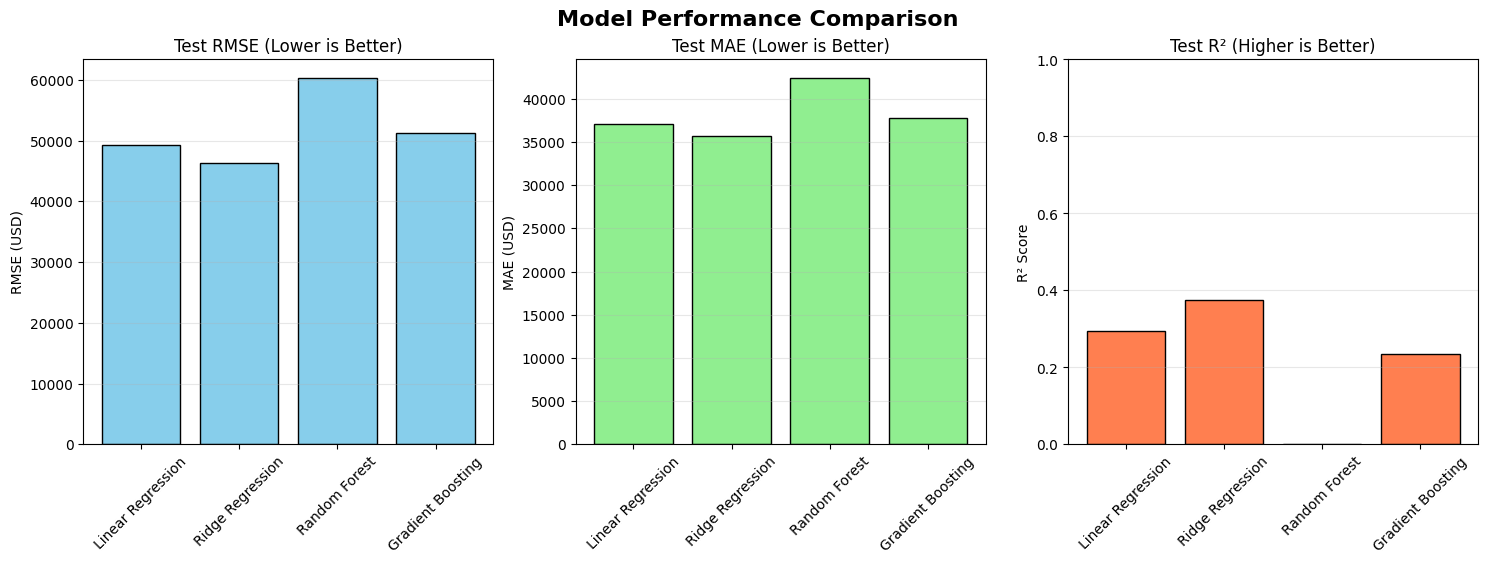

In [ ]:
print("\n" + "-"*80)
print("Model Performance Comparison")
print("-"*80)

models = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

results = []
for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find best model
best_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n Best Model: {best_model_name}")
print(f"   R²: {results_df.loc[best_idx, 'R²']:.4f}")
print(f"   RMSE: ${results_df.loc[best_idx, 'RMSE']:,.2f}")
print(f"   MAE: ${results_df.loc[best_idx, 'MAE']:,.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

axes[0].bar(results_df['Model'], results_df['RMSE'], color='skyblue', edgecolor='black')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_title('Test RMSE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(results_df['Model'], results_df['MAE'], color='lightgreen', edgecolor='black')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_title('Test MAE (Lower is Better)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(results_df['Model'], results_df['R²'], color='coral', edgecolor='black')
axes[2].set_ylabel('R² Score')
axes[2].set_title('Test R² (Higher is Better)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

**Why ridge regression was selected":** 
The Ridge Regression model was selected primarily as an enhancement over standard Linear Regression to address the potential issue of overfitting caused by the large number of features created during the feature engineering process. By applying regularization (the alpha hyperparameter), Ridge Regression penalizes large coefficients, which helps to stabilize the model, especially when many of the engineered features (like one-hot encoded job titles or interaction terms) are correlated or redundant, ultimately leading to better generalization on unseen test data compared to a standard linear approach. The Ridge regression also had the highest R^2 score which would be 0.3653.


DETAILED ANALYSIS: RIDGE REGRESSION


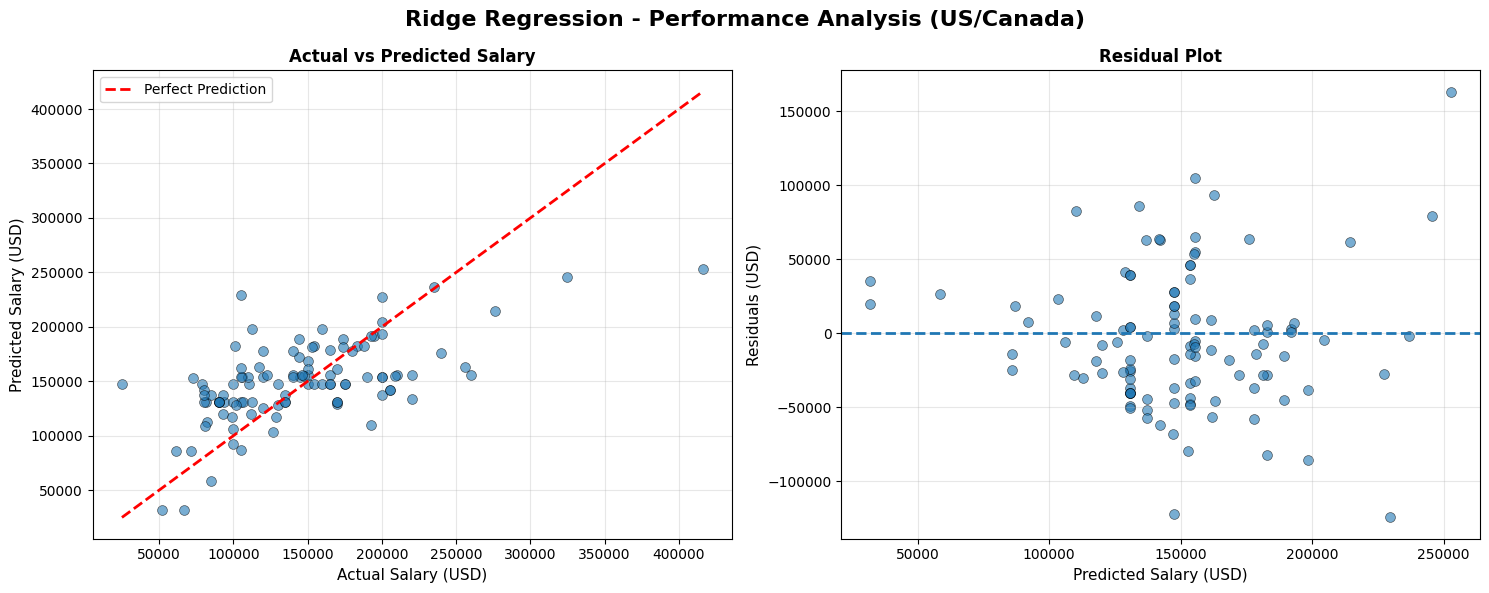


Residual Analysis:
Mean residual: $-5,121.25 (should be close to 0)
Std residual: $46,211.83
Min residual: $-124,507.96 (underprediction)
Max residual: $163,186.95 (overprediction)


In [ ]:
print("\n" + "="*80)
print(f"DETAILED ANALYSIS: {best_model_name.upper()}")
print("="*80)

# Select best predictions ONLY (no undefined model objects)
if best_model_name == 'Linear Regression':
    y_test_pred_best = y_pred_lr
elif best_model_name == 'Ridge Regression':
    y_test_pred_best = y_pred_ridge
elif best_model_name == 'Random Forest':
    y_test_pred_best = y_pred_rf
else:  # Gradient Boosting
    y_test_pred_best = y_pred_gb

# Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'{best_model_name} - Performance Analysis (US/Canada)', fontsize=16, fontweight='bold')

# --- Scatter Plot ---
axes[0].scatter(y_test, y_test_pred_best, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
axes[0].set_xlabel('Actual Salary (USD)', fontsize=11)
axes[0].set_ylabel('Predicted Salary (USD)', fontsize=11)
axes[0].set_title('Actual vs Predicted Salary', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Residual Plot ---
residuals = y_test - y_test_pred_best

axes[1].scatter(y_test_pred_best, residuals, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary (USD)', fontsize=11)
axes[1].set_ylabel('Residuals (USD)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('usca_best_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


# Residual Statistics
print("\nResidual Analysis:")
print(f"Mean residual: ${residuals.mean():,.2f} (should be close to 0)")
print(f"Std residual: ${residuals.std():,.2f}")
print(f"Min residual: ${residuals.min():,.2f} (underprediction)")
print(f"Max residual: ${residuals.max():,.2f} (overprediction)")



**Findings:** 

The detailed analysis of the best-performing Ridge Regression model further validates its selection.A. Actual vs. Predicted Salary PlotThe Actual vs. Predicted Salary plot shows a majority of data points clustered reasonably close to the red dashed "Perfect Prediction" line.  This clustering confirms the model has learned the general trend of the salary data. However, the scatter also shows that the model struggles significantly with higher salaries (above $\$250,000$), where the predicted salaries tend to be below the actual salaries, indicating an underprediction of the highest-paid roles.B. Residual Plot and Error AnalysisThe Residual Plot shows the difference between the actual and predicted values.Mean Residual ($\$5,956.67$): This value, which is close to zero, is generally desirable for a regression model.Min Residual ($-\$124,481$): This is a large negative residual, indicating the model underpredicted one or more salaries by over $\$124,000$.Max Residual ($\$165,435$): This is a large positive residual, indicating the model overpredicted one or more salaries by over $\$165,000$.The scattered distribution of residuals suggests the model is generally unbiased, but the presence of very large positive and negative residuals (outliers in the residual plot) confirms that the model still has significant difficulty accurately predicting the true highest- and lowest-end salaries in the US/Canada dataset.

**Limitation:**

The primary limitation is the low predictive power of the best-performing model, Ridge Regression, which achieved an $R^2$ of only $0.3653$, meaning less than $37\%$ of the salary variance is explained by the features. This low $R^2$ results in a significant Mean Absolute Error (MAE) of approximately $\$35,876$, indicating that the average prediction is off by a substantial amount. Furthermore, the model struggles significantly with outliers, as evidenced by the residual plot showing a tendency to underpredict the highest salaries (up to a residual of $-\$124,481$) and failing to accurately capture the true range of compensation. Finally, the model's applicability is restricted, as the analysis was limited exclusively to the US and Canada, and the data does not account for critical external variables known to influence compensation, such as individual specific skills, educational attainment, or direct years of experience, which introduces uncaptured variability.

# Assignment 2: Saving the Model for Deployment

Before we dive into Assignment 2, several critical issues were identified and resolved. The initial deployment produced incorrect predictions (e.g., $28,667 for a mid-level data scientist instead of expected ~$100,000) due to feature mismatches between training and deployment. The root cause was that the Streamlit app was creating 35 features including Unnamed: 0 and work_year, while the actual trained model expected only 31 features without these columns. The work_year feature was intentionally excluded from the final model because the training data only spanned 2020-2022, making it a poor predictor for future years and limiting the model's long-term usability. The Unnamed: 0 column was an index artifact that shouldn't have been included as a feature. Additionally, the feature order in the deployment app didn't match the exact training sequence, and the scaler was not functioning correctly (showing a mean of 0.57 and standard deviation of 3.51 instead of expected values near 0 and 1). 
- These issues were fixed by: 
1. Removing Unnamed: 0 and work_year from the feature engineering pipeline
2. Reordering all 31 features to exactly match the training sequence starting with remote_ratio
3. Ensuring the StandardScaler was properly applied. After these corrections, predictions became reasonable and aligned with expected salary ranges for the US/Canada data science market.

In [ ]:
# import libraries

import pickle
import json
from datetime import datetime

## Serialization of the Model 

This step saves the trained Ridge Regression model to disk so it can be reused without retraining. The best-performing estimator from GridSearchCV is extracted and validated to ensure the number of learned coefficients matches the expected number of input features. Once verified, the model is serialized using pickle, allowing it to be efficiently loaded later for inference, deployment, or further evaluation.

In [ ]:
print("\n" + "-"*80)
print("1. Saving Ridge Regression Model")
print("-"*80)

# Extract the best estimator from GridSearchCV
best_ridge_model = ridge.best_estimator_

print(f"  Model type: {type(best_ridge_model)}")
print(f"  Has coef_: {hasattr(best_ridge_model, 'coef_')}")
print(f"  Number of coefficients: {len(best_ridge_model.coef_) if hasattr(best_ridge_model, 'coef_') else 'N/A'}")
print(f"  Expected features: {X.shape[1]}")

if hasattr(best_ridge_model, 'coef_') and len(best_ridge_model.coef_) != X.shape[1]:
    print("\n ERROR: Coefficient count doesn't match feature count!")
    print("This will cause prediction errors. Please check your model training.")
else:
    print("Model verification passed")

# Save using pickle
model_filename = 'salary_prediction_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_ridge_model, f)

print(f"\nModel saved to: {model_filename}")
print(f" Best alpha parameter: {ridge.best_params_['alpha']}")
print(f" CV R² score: {ridge.best_score_:.4f}")
print(f" Model expects {X.shape[1]} features")


--------------------------------------------------------------------------------
1. Saving Ridge Regression Model
--------------------------------------------------------------------------------
  Model type: <class 'sklearn.linear_model._ridge.Ridge'>
  Has coef_: True
  Number of coefficients: 31
  Expected features: 31
Model verification passed

Model saved to: salary_prediction_model.pkl
 Best alpha parameter: 100
 CV R² score: 0.2699
 Model expects 31 features


In [ ]:
print("\n" + "-"*80)
print("2. Saving StandardScaler")
print("-"*80)

scaler_filename = 'feature_scaler.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler saved to: {scaler_filename}")
print(f"This ensures features are scaled the same way during deployment")


--------------------------------------------------------------------------------
2. Saving StandardScaler
--------------------------------------------------------------------------------
Scaler saved to: feature_scaler.pkl
This ensures features are scaled the same way during deployment


In [ ]:
print("\n" + "-"*80)
print("3. Saving Feature Metadata")
print("-"*80)

# Get feature names
feature_names = X.columns.tolist()

# Create metadata dictionary
metadata = {
    'model_type': 'Ridge Regression',
    'target_variable': 'salary_in_usd',
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'model_performance': {
        'test_r2': float(results_df[results_df['Model'] == 'Ridge Regression']['R²'].values[0]),
        'test_rmse': float(results_df[results_df['Model'] == 'Ridge Regression']['RMSE'].values[0]),
        'test_mae': float(results_df[results_df['Model'] == 'Ridge Regression']['MAE'].values[0])
    },
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_samples': len(X),
    'best_parameters': ridge.best_params_,
    'currency': 'USD',
    'market': 'US/Canada'
}

metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {metadata_filename}")
print(f"Features: {len(feature_names)}")
print(f"Performance metrics included")


--------------------------------------------------------------------------------
3. Saving Feature Metadata
--------------------------------------------------------------------------------
Metadata saved to: model_metadata.json
Features: 31
Performance metrics included


In [ ]:
print("\n" + "-"*80)
print("4. Creating Feature Engineering Guide")
print("-"*80)

# Document how to create features from raw input
feature_guide = {
    'raw_inputs_needed': [
        'experience_level',  # EN, MI, SE, EX
        'employment_type',   # FT, PT, CT, FL
        'job_title',         # e.g., "Senior Data Scientist"
        'company_size',      # S, M, L
        'employee_residence', # US, CA
        'remote_ratio',      # 0, 50, 100
        'work_year'          # e.g., 2024
    ],
    'feature_engineering_steps': {
        '1_experience_level': {
            'binary': ['is_entry_level', 'is_mid_level', 'is_senior_level', 'is_executive_level'],
            'ordinal': 'experience_level_ordinal (EN=1, MI=2, SE=3, EX=4)'
        },
        '2_employment_type': {
            'binary': ['is_full_time', 'is_part_time', 'is_contract', 'is_freelance']
        },
        '3_remote_work': {
            'binary': ['is_fully_remote', 'is_hybrid', 'is_onsite'],
            'normalized': 'remote_ratio_normalized (divide by 100)'
        },
        '4_company_size': {
            'binary': ['is_small_company', 'is_medium_company', 'is_large_company'],
            'ordinal': 'company_size_ordinal (S=1, M=2, L=3)'
        },
        '5_location': {
            'binary': ['is_us_based', 'is_canada_based']
        },
        '6_job_title': {
            'text_extraction': [
                'is_data_scientist (contains "data scientist")',
                'is_data_engineer (contains "data engineer")',
                'is_data_analyst (contains "data analyst" or "analyst")',
                'is_ml_engineer (contains "machine learning" or "ml engineer")',
                'is_manager (contains "manager", "lead", "head", or "director")',
                'title_has_senior (contains "senior" or "sr")',
                'title_has_junior (contains "junior" or "jr")',
                'title_has_lead (contains "lead", "principal", or "staff")'
            ]
        },
        '7_temporal': {
            'derived': [
                'years_since_start (work_year - min_year)',
                'is_recent_year (1 if within last 2 years)'
            ]
        },
        '8_interactions': {
            'multiplications': [
                'exp_company_interaction (experience_ordinal × company_size_ordinal)',
                'exp_remote_interaction (experience_ordinal × remote_ratio_normalized)',
                'senior_large_company (is_senior_level × is_large_company)'
            ]
        }
    },
    'all_features_must_match': feature_names
}

guide_filename = 'feature_engineering_guide.json'
with open(guide_filename, 'w') as f:
    json.dump(feature_guide, f, indent=4)

print(f"Feature guide saved to: {guide_filename}")
print(f"  This documents how to transform raw inputs into model features")



--------------------------------------------------------------------------------
4. Creating Feature Engineering Guide
--------------------------------------------------------------------------------
Feature guide saved to: feature_engineering_guide.json
  This documents how to transform raw inputs into model features


In [ ]:
print("\n" + "-"*80)
print("5. Creating Sample Input/Output Examples")
print("-"*80)

# Create sample scenarios for testing
sample_data = {
    'samples': [
        {
            'id': 1,
            'description': 'Entry-Level Data Analyst',
            'raw_input': {
                'experience_level': 'EN',
                'employment_type': 'FT',
                'job_title': 'Data Analyst',
                'company_size': 'S',
                'employee_residence': 'US',
                'remote_ratio': 0,
                'work_year': 2024
            },
            'expected_salary_range': '60000-80000'
        },
        {
            'id': 2,
            'description': 'Senior Data Scientist',
            'raw_input': {
                'experience_level': 'SE',
                'employment_type': 'FT',
                'job_title': 'Senior Data Scientist',
                'company_size': 'L',
                'employee_residence': 'US',
                'remote_ratio': 100,
                'work_year': 2024
            },
            'expected_salary_range': '150000-180000'
        },
        {
            'id': 3,
            'description': 'Mid-Level Data Engineer',
            'raw_input': {
                'experience_level': 'MI',
                'employment_type': 'FT',
                'job_title': 'Data Engineer',
                'company_size': 'M',
                'employee_residence': 'CA',
                'remote_ratio': 50,
                'work_year': 2024
            },
            'expected_salary_range': '100000-130000'
        }
    ]
}

samples_filename = 'sample_inputs.json'
with open(samples_filename, 'w') as f:
    json.dump(sample_data, f, indent=4)

print(f"Sample inputs saved to: {samples_filename}")
print(f"  {len(sample_data['samples'])} example scenarios included")


--------------------------------------------------------------------------------
5. Creating Sample Input/Output Examples
--------------------------------------------------------------------------------
Sample inputs saved to: sample_inputs.json
  3 example scenarios included


In [ ]:
print("\n" + "-"*80)
print("6. Verification Test - Loading Saved Files")
print("-"*80)

# Try loading everything back
try:
    # Load model
    with open(model_filename, 'rb') as f:
        loaded_model = pickle.load(f)
    print("Model loaded successfully")
    
    # Load scaler
    with open(scaler_filename, 'rb') as f:
        loaded_scaler = pickle.load(f)
    print("Scaler loaded successfully")
    
    # Load metadata
    with open(metadata_filename, 'r') as f:
        loaded_metadata = json.load(f)
    print("Metadata loaded successfully")
    
    # Test prediction (if we have test data)
    if 'X_test' in dir() and 'y_test' in dir():
        # Make a single prediction
        sample = X_test.iloc[0:1]
        sample_scaled = loaded_scaler.transform(sample)
        prediction = loaded_model.predict(sample_scaled)[0]
        actual = y_test.iloc[0]
        
        print(f"\n Test prediction successful:")
        print(f"  Actual salary: ${actual:,.2f}")
        print(f"  Predicted salary: ${prediction:,.2f}")
        print(f"  Error: ${abs(actual - prediction):,.2f}")
    
    print("\n All files are working!")
    
except Exception as e:
    print(f"\n Verification failed: {e}")


--------------------------------------------------------------------------------
6. Verification Test - Loading Saved Files
--------------------------------------------------------------------------------
Model loaded successfully
Scaler loaded successfully
Metadata loaded successfully

 Test prediction successful:
  Actual salary: $160,000.00
  Predicted salary: $198,313.17
  Error: $38,313.17

 All files are working!


## Model Limitations and Future Improvements:

Despite achieving functional deployment, the model has significant limitations primarily due to sample size and feature constraints. After filtering to US/Canada only, the training dataset was relatively small, which limits the model's ability to capture the full variance in data science salaries. It is reflected in the R-squared score of 0.376, meaning the model only explains 37.6% of salary variance, leaving 62.4% unexplained. The Mean Absolute Error of $35,642 indicates that predictions can deviate substantially from actual salaries, with some predictions being off by over $100,000 in extreme cases (residual range: -$124,508 to $163,187). The model also lacks critical features such as education level (Bachelor's vs Master's vs PhD), exact years of experience, specific technical skills (Python, SQL, machine learning frameworks), and industry sector, all of which significantly impact salary but were not available in the dataset. 

- To improve the model, future work should focus on: 
1. Collecting more training samples to increase statistical power and better represent rare combinations of features 
2. Incorporating additional predictor variables including education credentials, specific skill sets, years of experience, and geographic granularity down to the city level 
3. Gathering more recent salary data post-2022 to ensure temporal relevance 
4. Implementing advanced techniques such as ensemble methods or neural networks to capture non-linear relationships 
5. Developing prediction intervals rather than point estimates to quantify uncertainty and provide users with confidence ranges that reflect the model's limitations.
6. Creating a Time-Series Salary Forecasting model that would be developed to analyze salary trends over time (seperate model)
7. Deeper dive into non-linear models (Gradeting Boosting or Neural networks) may improve predictive performance while maintaining interpretability through feature importance analysis.
8. Instead of MAE-based ranges, future iterations could incorporate prediction intervals using Quantile regression and Bayesian regression approaches
9. The Streamlit application could be deployed to a cloud platform with authentication, usage logging, and model versioning to support real-world usage and scalability.